# `Classification semi-supervisée Fixmatch`
- __Implémentation de l'algorithme de en PyTorch__

Dans ce notebook, vous allez compléter le code de l'algorithme Fixmatch, et le tester sur CIFAR10 en utilisant seulement 250 exemples supervisés et le reste en non-supervisé.

À faire :
- compléter le code de la fonction `fixMatchstepAlgo()`, voir plus bas
- réaliser un apprentissage supervisé sur les 250 exemples supervisés, pour comparaison avec le même modèle entraîné avec Fixmatch.


<img src="https://www.irit.fr/~Thomas.Pellegrini/ens/M2ML3/fixmatch_diagram.png" alt="diagram FixMatch" width="800"/>


## `Contexte et notations`

### `Apprentissage semi-supervisé`

- Problème de classification à $L$ classes exclusives
- Exemples labélisés : $\cal{X} = \{(x_b,p_b) : b \in (1,...,B)\}$
- Exemples non-labélisés : $\cal{U} = \{u_b : b \in (1,...,\mu B)\}$
- Le modèle prédit un label pour l'entrée $x$ : $q = p_m (\text{target}|x; \theta)$
- Cross-Entropy : $H(p, q)$
- Augmentations faibles (weak): $\alpha(x)$.
  - Par exemple, rotations, translations, flips, etc
- Augmentations fortes (strong) : $\cal{A}(x)$.
  - Éventuellement, on pourrait utiliser des augmentations qui s'apprennent : AutoAugment, CTAugment, etc


### `Loss sur les données supervisées :`

- Cross-Entropy loss : $L(x, \text{class}) = - \log(q[\text{class}])$


### `Loss sur les données non-supervisées :`

- Consistency loss avec $\cal{l}^2$ : $L(x) = |p_m (\text{target}| \alpha_1(x); \theta) - p_m (\text{target}| \alpha_2(x); \theta)|^2$
- Ou Consistency loss avec Cross-Entropy : $p_m (\text{target}| \alpha_1(x); \theta) \rightarrow \text{target}$, $p_m (\text{target}| \alpha_2(x); \theta) \rightarrow \text{prédiction}$

### `Pseudo-labeling`

1) Le modèle génère des prédictions utilisées ensuite comme labels pour les données non-su+pervisées.

2) Fixmatch utilise des labels binaires ("hard labels"), et sélectionne uniquement celles dont la probabilité donnée par le modèle est supérieure à un seuil prédéfini :  

- Prédiction : $q = p_m (\text{target}|x; \theta)$
- Pseudo-label : $\hat{q} = \text{argmax}(q)$
- "Hard" label : $\max(q) \ge \tau$
- Loss :
  - $H(\hat{q}, q)$ if $\max(q) \ge \tau$
  - $0$ sinon


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lrs
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets.cifar import CIFAR10
from torchvision.models.resnet import resnet18
from torchvision.utils import make_grid

import matplotlib.pylab as plt
%matplotlib inline

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Assuming that we are on a MPS machine, this should print a CUDA device:
print(device)

cuda


In [ ]:
num_train_samples_per_class = 25
num_classes = 10
mu_ratio = 7
weight_decay = 0.0005

device = 'cuda'
batch_size = 64  # 64 dans le papier

### `CIFAR10 dataset`

In [ ]:
class TransformedDataset(Dataset):

    def __init__(self, dataset, transforms):
        self.dataset = dataset
        self.transforms = transforms

    def __getitem__(self, i):
        dp = self.dataset[i]
        return self.transforms(dp)

    def __len__(self):
        return len(self.dataset)

In [ ]:
rep_path= "./data/"
full_train_dataset = CIFAR10(rep_path, train=True, download=True)
full_test_dataset = CIFAR10(rep_path, train=False, download=False)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [ ]:
print(full_test_dataset.meta)
print(full_test_dataset.classes)

{'filename': 'batches.meta', 'key': 'label_names', 'md5': '5ff9c542aee3614f3951f8cda6e48888'}
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
supervised_train_indices = []
counter = [0] * num_classes

for i, dp in enumerate(full_train_dataset):
    if len(supervised_train_indices) >= num_classes * num_train_samples_per_class:
        break
    if counter[dp[1]] < num_train_samples_per_class:
        counter[dp[1]] += 1 # incrémente le nombre de classe par type [0, 2, 0, 0, 1, 0, 1, 0, 0, 2]
        supervised_train_indices.append(i)

print(f'sum(counter) : {sum(counter)}')
supervised_train_dataset = Subset(full_train_dataset, supervised_train_indices)
print(f'le nombre de classe pour le trainset est de {len(supervised_train_dataset)}')

sum(counter) : 250
le nombre de classe pour le trainset est de 250


## __`WiseNet`__
#### `TestLoader pour WiseNet`

In [ ]:
test_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25))
])

test_loaderWiseNet = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": test_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

#### `Supervised TrainLoader pour WiseNet`

In [ ]:
weak_transforms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.5, 0.5),
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25))
])

supervised_train_loaderWiseNet = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

#### `Extrait du dataset`

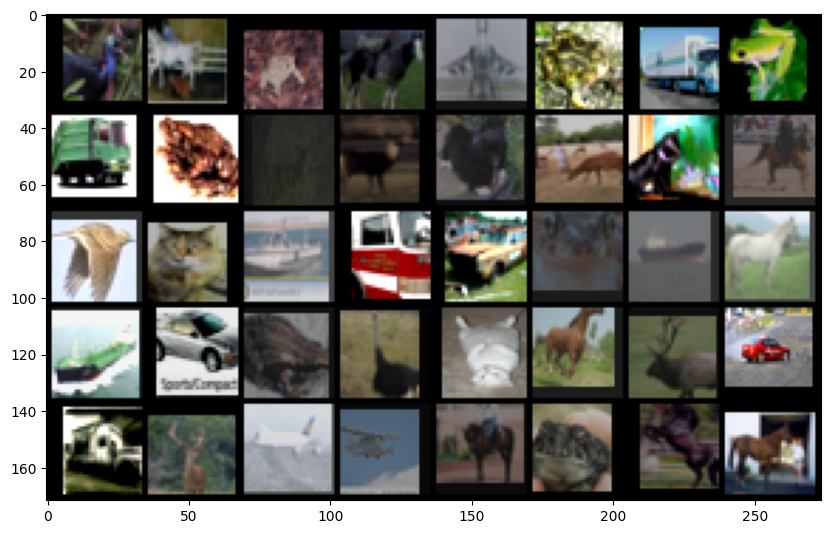

In [ ]:
supervised_train_loader_iter = iter(supervised_train_loaderWiseNet)
sup_batch = next(supervised_train_loader_iter)

sup_weak_aug_batch = make_grid(sup_batch["image"][:40, ...], normalize=True)
plt.figure(figsize=(10, 7))
plt.imshow(sup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

#### `Unsupervised TrainLoader pour WiseNet`

In [ ]:
strong_transforms = T.Compose([
    T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25)),
    T.RandomErasing(scale=(0.02, 0.15))
])

unsupervised_train_datasetWiseNet = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loaderWiseNet = DataLoader(
    unsupervised_train_datasetWiseNet,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `Extrait de la transformation`

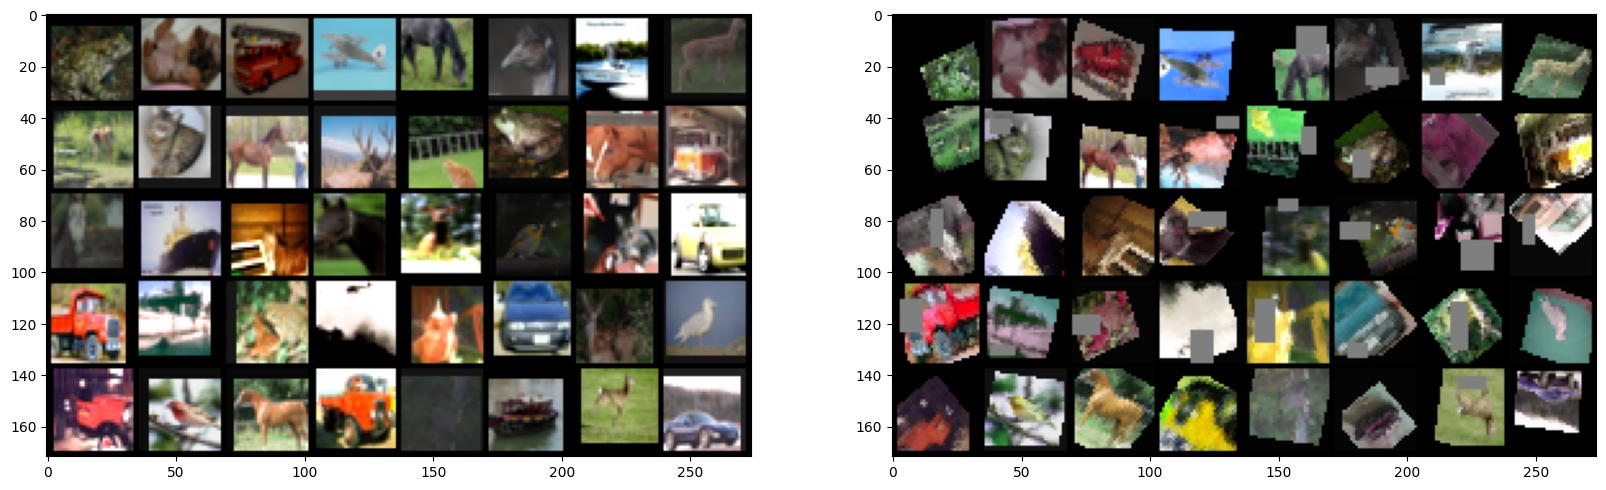

In [ ]:
unsupervised_train_loader_iter = iter(unsupervised_train_loaderWiseNet)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

### `Model. Wide-ResNet-28-2`

https://github.com/google-research/fixmatch/blob/08d9b83d7cc87e853e6afc5a86b12aacff56cdea/libml/models.py#L62

In [ ]:
import torch.nn as nn

class Residual(nn.Module):

    def __init__(self, in_channels, out_channels, stride, activate_before_residual=False):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.001)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels, momentum=0.001)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        self.activate_before_residual = activate_before_residual
        if in_channels == out_channels:
            self.skip = nn.Identity()
        else:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0)

    def forward(self, x0):
        x = self.leaky_relu(self.bn1(x0))
        if self.activate_before_residual:
            x0 = x
        x = self.leaky_relu( self.bn2( self.conv1(x) ) )
        x = self.conv2(x)
        x0 = self.skip(x0)
        return x0 + x


class WideResNet(nn.Module):

    def __init__(self, num_classes=10, scales=3, filters=32, repeat=4):
        super().__init__()
        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)

        b0 = nn.Sequential(
            Residual(16, filters, stride=1, activate_before_residual=True),
            *[Residual(filters, filters, stride=1) for _ in range(repeat - 1)]
        )
        b1 = nn.Sequential(
            Residual(filters, filters * 2, stride=2),
            *[Residual(filters * 2, filters * 2, stride=1) for _ in range(repeat - 1)]
        )
        b2 = nn.Sequential(
            Residual(filters * 2, filters * 4, stride=2),
            *[Residual(filters * 4, filters * 4, stride=1) for _ in range(repeat - 1)]
        )
        self.res_blocks = nn.Sequential(b0, b1, b2)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.bn = nn.BatchNorm2d(filters * 4, momentum=0.001)
        self.reduce = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(filters * 4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.res_blocks(x)
        x = self.bn(x)
        x = self.leaky_relu(x)
        x = self.reduce(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

### `FixMatch algorithme`

 - ligne 4, on fait passer dans le réseau les données fortement augmentées.
 - ligne 7, la cross-entropy H est calculée entre les targets, pseudo-labels obtenues avec argmax sur q_b
 - les logits obtenus par une passe forward sur les données augmentées fortement.

<p style="text-align:left;">
<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/fixmatchAlgo.png" alt="Méthode - FixMatch [Sohn, 2020]" style="width:120%; height:auto;" title="FixMatch Algorithme" />
</p>

In [ ]:
def sup_prepare_batch(batch, device, non_blocking):
    x = batch["image"].to(device, non_blocking=non_blocking)
    y = batch["target"].to(device, non_blocking=non_blocking)
    return x, y

In [ ]:
confidence_threshold = 0.95
lambda_u = 1.0

<p style="text-align:left;">
<img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/MixMatch.png" alt="Méthode - FixMatch [Sohn, 2020]" style="width:60%; height:auto;" title="Méthode - FixMatch [Sohn, 2020]" />
</p>

In [ ]:
# Cette fonction crée un itérateur infini sur ton dataloader,
# qui renvoie les batchs en boucle sans jamais s’arrêter.
# cycle donne un flux infini de batchs,
def cycle(dataloader):
    while True:
        for b in dataloader:
            yield b

#supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
#unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised

# Chaque appel à step() consomme un batch supervisé et un batch non supervisé.
def fixMatchstepAlgo(model,optimizer, lr_scheduler, sup_criterion,unsup_criterion):
    # 1. Mise en mode train et reset des gradients
    model.train()
    optimizer.zero_grad()

    # ----- partie supervisée -----
    # 2. Partie supervisée (batch labellisé)
    sup_batch = next(supervised_train_loader_iter) # weak_transforms supervised
    x, y = sup_prepare_batch(sup_batch, device, non_blocking=True) # x= image , y =target
    y_pred = model(x) # prédiction de classe
    sup_loss = sup_criterion(y_pred, y)   # scalaire = loss prédiction sur la prédiction

    # ----- partie pseudo-labeling (FixMatch) -----
    # 3. Partie non supervisée (FixMatch, pseudo‑labels)
    unsup_batch = next(unsupervised_train_loader_iter) # batch strong_aug_transforms unsupervised
    weak_x = unsup_batch["image"].to(device, non_blocking=True) # tensor image
    # weak_x.shape : torch.Size([896, 3, 32, 32])
    strong_x = unsup_batch["strong_aug"].to(device, non_blocking=True) # tensor augmentation
    # strong_x.shape : torch.Size([896, 3, 32, 32])

    # logits sur weak et strong
    # On obtient les logits sur weak et strong pour le même batch d’images.
    y_weak_logits = model(weak_x)  # retourne prédiction classes les images du batch weakly modified
    # print(f'y_weak_logits.shape : {y_weak_logits.shape}')     # y_weak_logits.shape : torch.Size([896, 10])
    y_strong_logits = model(strong_x)           # retourne la prédiction liée à la déformation
    # print(f'y_strong_logits.shape : {y_strong_logits.shape}') # y_strong_logits.shape : torch.Size([896, 10])

    # 1) pseudo-labels à partir des weak
    y_weak_probs = torch.softmax(y_weak_logits, dim=1)
    # print(f'y_weak_probs.shape : {y_weak_probs.shape}') # y_weak_probs.shape : torch.Size([896, 10])
    y_pseudo = torch.argmax(y_weak_probs, dim=1)
    # print(f'y_pseudo.shape : {y_pseudo.shape}') # y_pseudo.shape : torch.Size([896])
    # 2) confiance de la classe prédite
    max_probs = y_weak_probs.gather(1, y_pseudo.unsqueeze(1)).squeeze(1)  # (B,)
    # print(f'max_probs.shape : {max_probs.shape}') # max_probs.shape : torch.Size([896])
    unsup_loss_mask = max_probs >= confidence_threshold                   # (B,) bool
    # print(f'unsup_loss_mask[:10] : {unsup_loss_mask[:10]}') #[False, True,... False, False]
    # 3) loss non supervisée par échantillon
    per_sample_unsup_loss = unsup_criterion(y_strong_logits, y_pseudo)    # (B,)

    # 4) garder seulement les échantillons confiants et moyenner
    #.   True si au moins un échantillon du batch est confiant.
    #    False si aucun échantillon ne dépasse le seuil de confiance
    if unsup_loss_mask.any(): # retourne un scalaire booléen
        unsup_loss = per_sample_unsup_loss[unsup_loss_mask].mean()
    else:
        unsup_loss = torch.tensor(0.0, device=device)
    # ----- loss totale -----
    total_loss = sup_loss + lambda_u * unsup_loss    # scalaire

    total_loss.backward()
    optimizer.step()
    lr_scheduler.step()

    return {
    "total_loss": total_loss.item(),
    "sup_loss": sup_loss.item(),
    "unsup_loss": unsup_loss.item(),
    "non_zero_unsup_loss_density": unsup_loss_mask.float().mean().item(),
    }

`Accuracy`.  
 - cette fonction calcule la précision « top‑k »,
 - c’est‑à‑dire le % d’images dont la vraie classe est dans les k prédictions les plus probables du modèle.
`output.topk(maxk, dim=1, largest=True, sorted=True)`
Le tenseur output de taille (batch_size, num_classes) contient les scores (logits) de chaque classe :
 - la fonction topk, pour chaque élément du batch, prends les maxk classes ayant les scores les plus élevés, et retourne les indices.
 - on écrit _, pred = ..., implique que l'on ne conserve que les indices des classes dans pred.
 - si maxk = 5, alors pour chaque élément du batch on obtient les indices des 5 classes les plus probables.

On transpose pour avoir pred de forme (maxk,batch_size) :
 - chaque colonne = un exemple,
 - chaque ligne = la 1re, 2e, ..., k‑ème meilleure prédiction.

__`précision en pourcentage d’exemples pour lesquels la classe prédite la plus probable est exactement le label vrai`__
 - __prec1__ : pourcentage pour lesquel la classe prédite la plus probable est exactement le label vrai.
 - __prec5__ : pourcentage pour lesquels le label vrai est dans les 5 classes les plus probables du modèle`.

In [ ]:
def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)
    # output: (batch_size, num_classes)
    # la fonction topk les retourne les maxk plus grands scores sur la dimension des classes (dim=1),
    # et les indices de ces scores (c’est‑à‑dire les indices de classes).
    # pred: (batch_size, maxk) sont les indices des maxk classes les plus probables
    _, pred = output.topk(maxk, 1, True, True)
    # on transpose pour obtenir (maxk, batch_size)
    pred = pred.t()
    # target: (batch_size,) -> reshape en (1, batch_size)
    # expand_as(pred): (maxk, batch_size)
    # correct: booléen, True si la target est dans le top-k
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))

    res = []
    for k in topk:
        # on ne garde que les k premières lignes (top-k)
        # puis on aplatit, convertit en float (True=1, False=0) et on somme
        correct_k = correct[:k].reshape(-1).float().sum(0)
       # pourcentage d’exemples corrects dans le batch
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

def test(device, sup_criterion, test_loader, model, epoch):
    test_loss = 0.0
    top1 = 0.0
    top5 = 0.0

    with torch.no_grad():
        for batch_idx, dico in enumerate(test_loader):
            model.eval()

            inputs = dico["image"]
            targets = dico["target"]
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = sup_criterion(outputs, targets)

            prec1, prec5 = accuracy(outputs, targets, topk=(1, 5))
            test_loss += loss.item()
            top1 += prec1.item()
            top5 += prec5.item()

            # print("Test Iter: {batch:4}/{iter:4}. Loss: {loss:.4f}. top1: {top1:.2f}. top5: {top5:.2f}. ".format(
            #         batch=batch_idx + 1,
            #         iter=len(test_loader),
            #         loss=test_loss,
            #         top1=top1,
            #         top5=top5,
            # ))

    print("test top-1 acc: {:.2f} % pour lesquel la classe prédite la plus probable est exactement le label vrai".format(top1/len(test_loader)))
    print("test top-5 acc: {:.2f} % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle".format(top5/len(test_loader)))
    return test_loss/len(test_loader), top1/len(test_loader)

### `Instantiation du modèle WideResnet`

In [ ]:
modelWideResNet = WideResNet(num_classes=10).to(device)

if torch.mps.device_count() > 1:
    modelWideResNet = nn.parallel.DataParallel(modelWideResNet)

sup_criterion = nn.CrossEntropyLoss()
unsup_criterion = nn.CrossEntropyLoss(reduction='none')
optimizer = optim.SGD(modelWideResNet.parameters(), lr=0.03, momentum=0.9, nesterov=True, weight_decay=weight_decay)
print(f'nombre de paramètre : {sum([p.numel() for p in modelWideResNet.parameters()])}')

num_epochs = 1024  # orginally 1024
epoch_length = pow(2,16) // batch_size
K = num_epochs * epoch_length
lr_scheduler = lrs.CosineAnnealingLR(optimizer, K)

nombre de paramètre : 1469642


## __`Entraînement`__
:::
__`Lancement de la procédure de test avant l'entrainement du modèle ?`__.  
 - C’est une pratique standard en entraînement de modèles :
 - On mesure la performance du modèle à l’état initial (poids aléatoires, ou pretrained non fine‑tuné).
 - Ensuite, à chaque epoch, on appelle le test(...) pour suivre l'évolution de la performance.
 - Cela permet de tracer un graphe epoch → accuracy où le point epoch=0 est la baseline.
:::
:::
__`REMARQUE:`__    
 - `Les valeurs de loss s'accumulent au cours des mini-batchs,`
 - `c'est la raison pour laquelle, elles augmentent au cours des epochs!`
:::

### `Apprentissage du modèle WideResnet`

In [ ]:
epoch = 64
model = modelWideResNet
supervised_train_loader_iter = cycle(supervised_train_loaderWiseNet) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loaderWiseNet) # Weak + strong_aug_transforms unsupervised

print(f'############# Débul du calcul de la performance du modèle WiseNet à l\'état initial #####################')
test_loss, test_top1_acc = test(device, sup_criterion, test_loaderWiseNet, modelWideResNet, epoch)
print(f'############# Début de l\'apprentissage modèle WiseNet #####################')

for epoch in range(num_epochs):
    epoch_total_loss, epoch_sup_loss, epoch_unsup_loss  = 0., 0., 0.

    for it in range(epoch_length):
        dico = fixMatchstepAlgo(model,optimizer, lr_scheduler, sup_criterion,unsup_criterion)
        epoch_total_loss += dico["total_loss"]
        epoch_sup_loss += dico["sup_loss"]
        epoch_unsup_loss += dico["unsup_loss"]

        if it % 1000 == 0:
          print("Batch: {it}/{epoch_length:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
              it=it,
              epoch_length=epoch_length,
              epoch_total_loss=epoch_total_loss,
              epoch_sup_loss=epoch_sup_loss,
              epoch_unsup_loss=epoch_unsup_loss
          ))

    epoch_total_loss /= epoch_length
    epoch_sup_loss /= epoch_length
    epoch_unsup_loss /= epoch_length
    print("Train Epoch: {epoch}/{num_epochs:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
        epoch=epoch+1,
        num_epochs=num_epochs,
        epoch_total_loss=epoch_total_loss,
        epoch_sup_loss=epoch_sup_loss,
        epoch_unsup_loss=epoch_unsup_loss
    ))
    print(f"############# Début du test modèle WiseNet ################################")
    test_loss, test_top1_acc = test(device, sup_criterion, test_loaderWiseNet, model, epoch)

############# Débul du calcul de la performance du modèle WiseNet à l'état initial #####################
test top-1 acc: 9.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 50.17 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle WiseNet #####################
Batch: 0/1024 --- Loss: 2.31337 sup_loss: 2.31337 unsup_loss: 0.00000
Batch: 1000/1024 --- Loss: 2101.31189 sup_loss: 1970.15073 unsup_loss: 131.16117
Train Epoch: 1/ 512 --- Loss: 2.08875 sup_loss: 1.96067 unsup_loss: 0.12809
############# Début du test modèle WiseNet ################################
test top-1 acc: 25.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 80.02 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.73449 sup_loss: 1.73449 unsup_loss: 0.00000
Batch: 1000/1024 --- Loss: 1925.31481

### `Nettoyage de la mémoire`

In [ ]:
# 1. Modèle + optimizer
del modelWideResNet
del optimizer

# 2. Datasets + DataLoader liés à cette expérience
del unsupervised_train_datasetWiseNet
del test_loaderWiseNet
del supervised_train_loaderWiseNet
del unsupervised_train_loaderWiseNet

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
torch.cuda.empty_cache()   # sur Mac


## __`ResNet18 pré-trained`__

Le ResNet18 pré‑entraîné ImageNet est conçu pour 1000 classes.
Sa dernière couche est typiquement Linear(in_features=512, out_features=1000, bias=True)
CIFAR10 n’a que 10 classes, nous devons donc remplacer cette couche

### `Instantiation du modèle Resnet`

In [ ]:
from torchvision import models, transforms
import torch.nn as nn

num_classes = 10
device="cuda"

# modèle
modelresnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelresnet18.fc = nn.Linear(modelresnet18.fc.in_features, num_classes)
modelresnet18 = modelresnet18.to(device)

##
print(f'nombre de paramètre : {sum([p.numel() for p in modelresnet18.parameters()])}')
##
sup_criterion = nn.CrossEntropyLoss()
unsup_criterion = nn.CrossEntropyLoss(reduction='none')
optimizer = optim.AdamW(modelresnet18.parameters(), lr=1e-3, weight_decay=1e-2)
##
num_epochs = 1024  # orginally 1024
epoch_length = pow(2,16) // batch_size
K = num_epochs * epoch_length
print(f'num_epochs : {num_epochs} , epoch_length : {epoch_length}, K : {K}')
lr_scheduler = lrs.CosineAnnealingLR(optimizer, K)

nombre de paramètre : 11181642
num_epochs : 512 , epoch_length : 1024, K : 524288


#### `Test TrainLoader pour ResNet18`
:::
 - ResNet18 pré‑entraîné l'a été sur ImageNet avec des images 224×224 RGB, et une normalisation spécifique (moyennes/écarts‑types ImageNet).
 - CIFAR10 fournit des images 32×32, non normalisées comme ImageNet,
 - Si l'on n'adapte pas les caractéristiques de transforms, les images en 32×32 passent quand même,
 - par contre les features apprises sur 224×224 ne sont plus exploitées de manière cohérente (réception field, downsampling, etc.).
 - Avec CIFAR10 la distribution des pixels vue par le réseau étant très différente de ce qu’il a vu pendant le pré‑entraînement
 - Ne pas utiliser la bonne normalisation rompt l’intérêt du transfert.
:::

In [ ]:
# transform pour CIFAR10 (weak augment pour le supervisé par ex.)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean,std=imagenet_std),
])
test_loaderResNet = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": transform_test(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

#### `Supervised TrainLoader pour ResNet18`

In [ ]:
# Weak augmentation (FixMatch)
weak_transforms = T.Compose([
    T.Resize(256),
    T.RandomCrop(224, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

supervised_train_loaderResNet = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

#### `Unsupervised TrainLoader pour ResNet`

In [ ]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

strong_transforms = T.Compose([
    T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    T.Resize(256),
    T.RandomCrop(224, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
    T.RandomErasing(scale=(0.02, 0.15))
])

unsupervised_train_datasetResNet = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loaderResNet = DataLoader(
    unsupervised_train_datasetResNet,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `Extrait de la transformation`

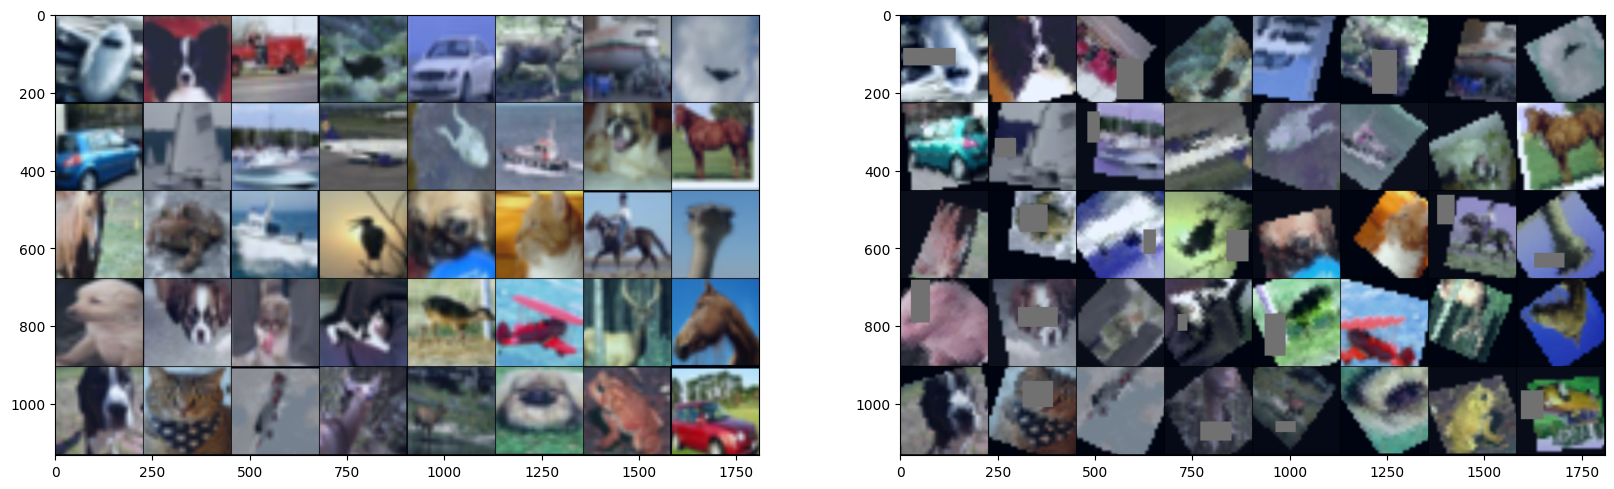

In [ ]:
unsupervised_train_loader_iter = iter(unsupervised_train_loaderResNet)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

##### `Apprentissage du modèle ResNet18`.   
- ResNet-18 pré‑entraîné « standard » pour classifier 1000 classes, celles du dataset ImageNet (ILSVRC)

In [ ]:
epoch = 64
model = modelresnet18

supervised_train_loader_iter = cycle(supervised_train_loaderResNet) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loaderResNet) # Weak + strong_aug_transforms unsupervised

print(f'############# Débul du calcul de la performance du modèle ResNet18 à l\'état initial #####################')
test_loss, test_top1_acc = test(device, sup_criterion, test_loaderResNet, model, epoch)
print(f'############# Début de l\'apprentissage modèle ResNet18 #####################')
for epoch in range(num_epochs):
    epoch_total_loss, epoch_sup_loss, epoch_unsup_loss  = 0., 0., 0.

    for it in range(epoch_length):
        dico = fixMatchstepAlgo(model,optimizer, lr_scheduler, sup_criterion,unsup_criterion)
        epoch_total_loss += dico["total_loss"]
        epoch_sup_loss += dico["sup_loss"]
        epoch_unsup_loss += dico["unsup_loss"]

        if it % 50 == 0:
          print("Batch: {it}/{epoch_length:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
              it=it,
              epoch_length=epoch_length,
              epoch_total_loss=epoch_total_loss,
              epoch_sup_loss=epoch_sup_loss,
              epoch_unsup_loss=epoch_unsup_loss
          ))

    epoch_total_loss /= epoch_length
    epoch_sup_loss /= epoch_length
    epoch_unsup_loss /= epoch_length
    print("Train Epoch: {epoch}/{num_epochs:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
        epoch=epoch+1,
        num_epochs=num_epochs,
        epoch_total_loss=epoch_total_loss,
        epoch_sup_loss=epoch_sup_loss,
        epoch_unsup_loss=epoch_unsup_loss
    ))
    print(f'############# Début du test modèle ResNet ################################')
    test_loss, test_top1_acc = test(device, sup_criterion, test_loaderResNet, model, epoch)


############# Débul du calcul de la performance du modèle ResNet18 à l'état initial #####################
test top-1 acc: 9.73 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 46.51 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle ResNet18 #####################
Batch: 0/1024 --- Loss: 2.44970 sup_loss: 2.44970 unsup_loss: 0.00000
Batch: 50/1024 --- Loss: 60.78110 sup_loss: 27.87124 unsup_loss: 32.90986
Batch: 100/1024 --- Loss: 92.84706 sup_loss: 32.51131 unsup_loss: 60.33575
Batch: 150/1024 --- Loss: 119.79441 sup_loss: 35.29986 unsup_loss: 84.49455
Batch: 200/1024 --- Loss: 145.02453 sup_loss: 37.50908 unsup_loss: 107.51546
Batch: 250/1024 --- Loss: 167.92306 sup_loss: 39.03866 unsup_loss: 128.88440
Batch: 300/1024 --- Loss: 191.19172 sup_loss: 40.94450 unsup_loss: 150.24722
Batch: 350/1024 --- Loss: 212.16433 sup_loss: 42.02644 unsup_loss: 170.13790
Batch: 400

### `Nettoyage de la mémoire`

In [ ]:
# 1. Modèle + optimizer
del modelresnet18
del optimizer

# 2. Datasets + DataLoader liés à cette expérience
del full_test_dataset
del full_train_dataset
del supervised_train_loaderResNet
del unsupervised_train_datasetResNet
del test_loaderResNet
del supervised_train_loaderResNet
del unsupervised_train_loaderResNet

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
torch.mps.empty_cache()   # sur Mac